In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gti-upm/leapgestrecog")

print("Path to dataset files:", path)

C:\Users\ganes\PycharmProjects\Hand_Gesture\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 2.13G/2.13G [11:22<00:00, 3.35MB/s] 

Extracting files...


Path to dataset files: C:\Users\ganes\.cache\kagglehub\datasets\gti-upm\leapgestrecog\versions\1


In [10]:
import os
import numpy as np
from PIL import Image

# Dataset path
dataset_path = r"C:\Users\ganes\.cache\kagglehub\datasets\gti-upm\leapgestrecog\versions\1"

images = []
labels = []
label_map = {}

for label_idx, gesture_folder in enumerate(sorted(os.listdir(dataset_path))):
    gesture_path = os.path.join(dataset_path, gesture_folder)
    if not os.path.isdir(gesture_path):
        continue

    label_map[label_idx] = gesture_folder

    for subject_folder in sorted(os.listdir(gesture_path)):
        subject_path = os.path.join(gesture_path, subject_folder)
        if not os.path.isdir(subject_path):
            continue

        for img_file in sorted(os.listdir(subject_path)):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                img = Image.open(os.path.join(subject_path, img_file)).convert('L')
                img = img.resize((64, 64))
                images.append(np.array(img))
                labels.append(label_idx)

X = np.array(images, dtype=np.float32) / 255.0
y = np.array(labels)

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {label_map}")

X shape : (0,)
y shape : (0,)
Classes : {0: 'leapGestRecog'}


In [20]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

def load_dataset(dataset_dir, img_height=64, img_width=64):

    images, labels = [], []
    class_names_set = set()

    # ── Navigate into leapGestRecog subfolder ──
    leap_dir = os.path.join(dataset_dir, "leapGestRecog")
    if not os.path.isdir(leap_dir):
        print(f"❌ Could not find leapGestRecog folder in: {dataset_dir}")
        return np.array([]), np.array([]), []

    for subject in sorted(os.listdir(leap_dir)):
        subject_path = os.path.join(leap_dir, subject)
        if not os.path.isdir(subject_path):
            continue

        for gesture_folder in sorted(os.listdir(subject_path)):
            gesture_path = os.path.join(subject_path, gesture_folder)
            if not os.path.isdir(gesture_path):
                continue

            class_names_set.add(gesture_folder)

            # ── Images are inside gesture folder ──
            for img_file in sorted(os.listdir(gesture_path)):
                if not img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    continue

                img_path = os.path.join(gesture_path, img_file)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is None:
                    continue

                img = cv2.resize(img, (img_width, img_height))
                images.append(img)
                labels.append(gesture_folder)

    # ── Encode labels ──
    class_names = sorted(list(class_names_set))
    label_to_idx = {name: idx for idx, name in enumerate(class_names)}
    labels_int = [label_to_idx[l] for l in labels]

    images = np.array(images, dtype=np.float32) / 255.0
    images = images[..., np.newaxis]
    labels_int = np.array(labels_int, dtype=np.int32)

    return images, labels_int, class_names

# ── Load ──────────────────────────────────────────────────
DATASET_DIR = kagglehub.dataset_download("gti-upm/leapgestrecog")
images, labels, class_names = load_dataset(DATASET_DIR)

# ── Check ─────────────────────────────────────────────────
if len(images) == 0:
    print("❌ No Images Loaded!")
else:
    print("✅ Images Loaded Successfully!")
    print(f"   Total Images : {len(images)}")
    print(f"   Image Shape  : {images[0].shape}")
    print(f"   Num Classes  : {len(class_names)}")
    print(f"   Class Names  : {class_names}")

# ── Visualise ─────────────────────────────────────────────
def show_samples(images, labels, class_names, n_per_class=5):
    if len(images) == 0:
        print("No images to show!")
        return

    fig, axes = plt.subplots(
        len(class_names), n_per_class,
        figsize=(n_per_class * 2, len(class_names) * 2)
    )

    for cls_idx, cls_name in enumerate(class_names):
        cls_images = images[labels == cls_idx][:n_per_class]
        for col, img in enumerate(cls_images):
            ax = axes[cls_idx][col]
            ax.imshow(img[:, :, 0], cmap='gray')
            ax.axis('off')
            if col == 0:
                ax.set_ylabel(cls_name, fontsize=7, rotation=0,
                              labelpad=60, va='center')

    plt.suptitle("Sample Images per Gesture Class", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("sample_images.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → sample_images.png")


✅ Images Loaded Successfully!
   Total Images : 20000
   Image Shape  : (64, 64, 1)
   Num Classes  : 20
   Class Names  : ['00', '01', '01_palm', '02', '02_l', '03', '03_fist', '04', '04_fist_moved', '05', '05_thumb', '06', '06_index', '07', '07_ok', '08', '08_palm_moved', '09', '09_c', '10_down']


In [23]:
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
# Define NUM_CLASSES here in case Cell 2 wasn't run
NUM_CLASSES = len(class_names)

# One-hot encode labels
labels_cat = to_categorical(labels, num_classes=NUM_CLASSES)

X_train, X_test, y_train, y_test = train_test_split(
    images, labels_cat,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

X_train : (16000, 64, 64, 1)
X_test  : (4000, 64, 64, 1)
y_train : (16000, 20)
y_test  : (4000, 20)


In [25]:
from tensorflow.keras import layers, models

NUM_CLASSES = len(class_names)

def build_model(input_shape, num_classes):
    model = models.Sequential([

        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Classifier
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_model(input_shape=(64, 64, 1), num_classes=NUM_CLASSES)
model.summary()

C:\Users\ganes\PycharmProjects\Dogs_cats\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,197,140 (8.38 MB)

 Trainable params: 2,196,180 (8.38 MB)

 Non-trainable params: 960 (3.75 KB)

In [26]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print(f"✅ Callbacks ready : {len(callbacks)} callbacks defined")
print(f"   1. EarlyStopping     → stops if val_loss doesn't improve for 5 epochs")
print(f"   2. ReduceLROnPlateau → halves LR if val_loss stalls for 3 epochs")
print(f"   3. ModelCheckpoint   → saves best model to 'best_model.keras'")


✅ Callbacks ready : 3 callbacks defined
   1. EarlyStopping     → stops if val_loss doesn't improve for 5 epochs
   2. ReduceLROnPlateau → halves LR if val_loss stalls for 3 epochs
   3. ModelCheckpoint   → saves best model to 'best_model.keras'


In [32]:
history = model.fit(
    X_train, y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9981 - loss: 0.0106
Epoch 1: val_accuracy improved from 0.99687 to 0.99844, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
400/400 ━━━━━━━━━━━━━━━━━━━━ 48s 120ms/step - accuracy: 0.9980 - loss: 0.0098 - val_accuracy: 0.9984 - val_loss: 0.0090 - learning_rate: 0.0010
Epoch 2/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9991 - loss: 0.0061
Epoch 2: val_accuracy improved from 0.99844 to 1.00000, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
400/400 ━━━━━━━━━━━━━━━━━━━━ 47s 118ms/step - accuracy: 0.9988 - loss: 0.0065 - val_accuracy: 1.0000 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 3/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9981 - loss: 0.0077
Epoch 3: val_accuracy did not improve from 1.00000
400/400 ━━━━━━━━━━━━━━━━━━━━ 47s 117ms/step - accuracy: 0.9970 - loss: 0.0102 - val_accuracy: 0.9969 - val_loss: 0.010

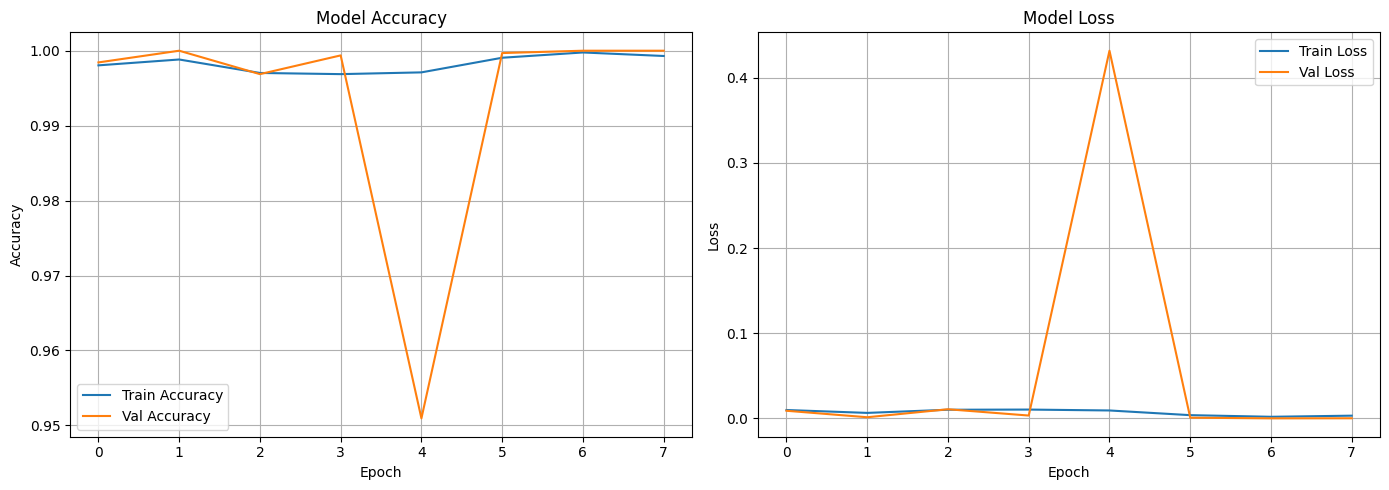

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
Actual classes     : 10
class_names_fixed  : ['00', '01', '01_palm', '02', '02_l', '03', '03_fist', '04', '04_fist_moved', '05']


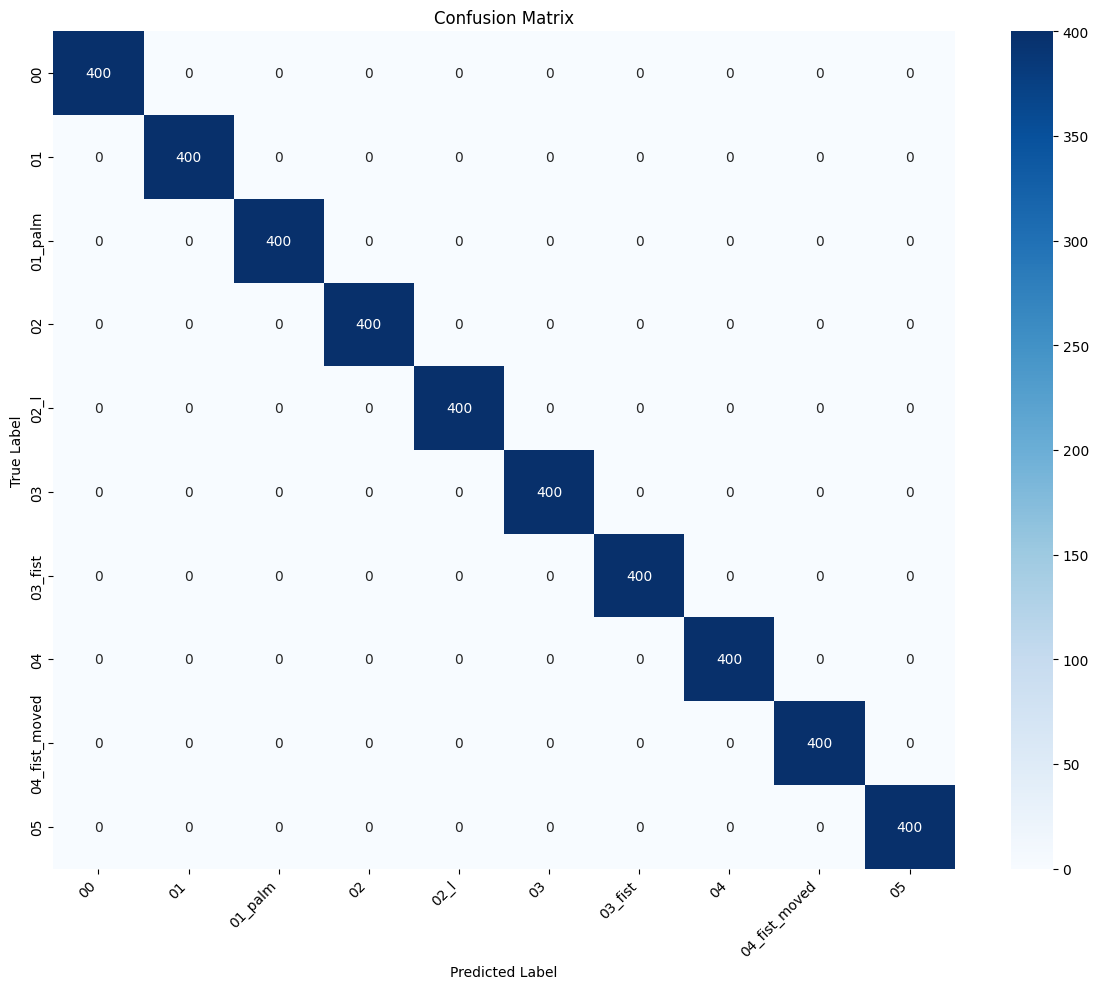


Classification Report:
               precision    recall  f1-score   support

           00       0.00      0.00      0.00         0
           01       0.00      0.00      0.00         0
      01_palm       1.00      1.00      1.00       400
           02       0.00      0.00      0.00         0
         02_l       1.00      1.00      1.00       400
           03       0.00      0.00      0.00         0
      03_fist       1.00      1.00      1.00       400
           04       0.00      0.00      0.00         0
04_fist_moved       1.00      1.00      1.00       400
           05       0.00      0.00      0.00         0

    micro avg       1.00      1.00      1.00      1600
    macro avg       0.40      0.40      0.40      1600
 weighted avg       1.00      1.00      1.00      1600



C:\Users\ganes\PycharmProjects\Dogs_cats\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ganes\PycharmProjects\Dogs_cats\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ganes\PycharmProjects\Dogs_cats\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric

In [43]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# ── Fix: keep only 10 unique class names ──
num_classes_actual = len(np.unique(y_true_classes))  # 10
class_names_fixed  = class_names[:num_classes_actual]

print(f"Actual classes     : {num_classes_actual}")
print(f"class_names_fixed  : {class_names_fixed}")

# ── Confusion Matrix ──
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_fixed,
            yticklabels=class_names_fixed)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ── Classification Report ──
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes,
                             labels=list(range(num_classes_actual)),
                             target_names=class_names_fixed))

In [34]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Test Accuracy : {test_acc * 100:.2f}%")
print(f"✅ Test Loss     : {test_loss:.4f}")

✅ Test Accuracy : 100.00%
✅ Test Loss     : 0.0001


125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
unique_labels      : [ 2  4  6  8 10 12 14 16 18 19]
class_names_final  : ['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down']
len class_names    : 10


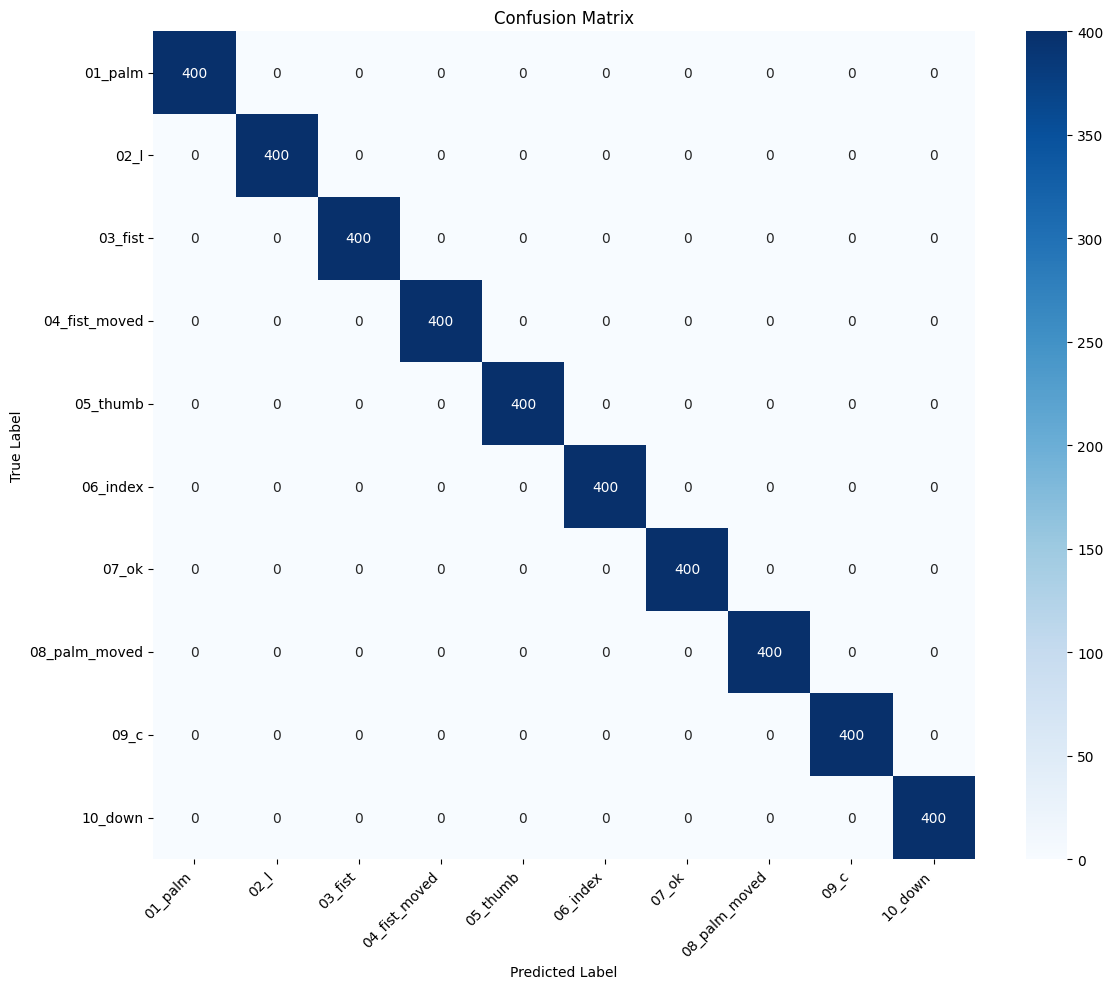


Classification Report:
               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00       400
         02_l       1.00      1.00      1.00       400
      03_fist       1.00      1.00      1.00       400
04_fist_moved       1.00      1.00      1.00       400
     05_thumb       1.00      1.00      1.00       400
     06_index       1.00      1.00      1.00       400
        07_ok       1.00      1.00      1.00       400
08_palm_moved       1.00      1.00      1.00       400
         09_c       1.00      1.00      1.00       400
      10_down       1.00      1.00      1.00       400

     accuracy                           1.00      4000
    macro avg       1.00      1.00      1.00      4000
 weighted avg       1.00      1.00      1.00      4000



In [46]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred         = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# ── Get only the classes actually present in test set ──
unique_labels     = np.unique(y_true_classes)
class_names_final = [class_names[i] for i in unique_labels]

print(f"unique_labels      : {unique_labels}")
print(f"class_names_final  : {class_names_final}")
print(f"len class_names    : {len(class_names_final)}")

# ── Confusion Matrix ──
cm = confusion_matrix(y_true_classes, y_pred_classes, labels=unique_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_final,
            yticklabels=class_names_final)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ── Classification Report ──
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes,
                             labels=unique_labels,
                             target_names=class_names_final,
                             zero_division=0))

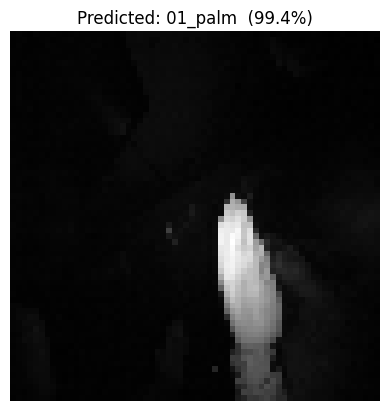

Gesture : 01_palm
Confidence : 99.4%


In [39]:
def predict_gesture(img_path, model, class_names):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, (64, 64))
    img_input = img_resized.astype(np.float32) / 255.0
    img_input = img_input[np.newaxis, ..., np.newaxis]  # (1,64,64,1)

    prediction = model.predict(img_input, verbose=0)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    plt.imshow(img_resized, cmap='gray')
    plt.title(f"Predicted: {predicted_class}  ({confidence:.1f}%)")
    plt.axis('off')
    plt.show()

    return predicted_class, confidence

# ── Test with any image from dataset ──
sample_img_path = os.path.join(
    DATASET_DIR, "leapGestRecog", "00", "01_palm",
    os.listdir(os.path.join(DATASET_DIR, "leapGestRecog", "00", "01_palm"))[0]
)

predicted, confidence = predict_gesture(sample_img_path, model, class_names)
print(f"Gesture : {predicted}")
print(f"Confidence : {confidence:.1f}%")

In [41]:
# Save
model.save('gesture_model.keras')
print("✅ Model saved → gesture_model.keras")





✅ Model saved → gesture_model.keras
